In [13]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
from tqdm import tqdm
import random
from collections import Counter

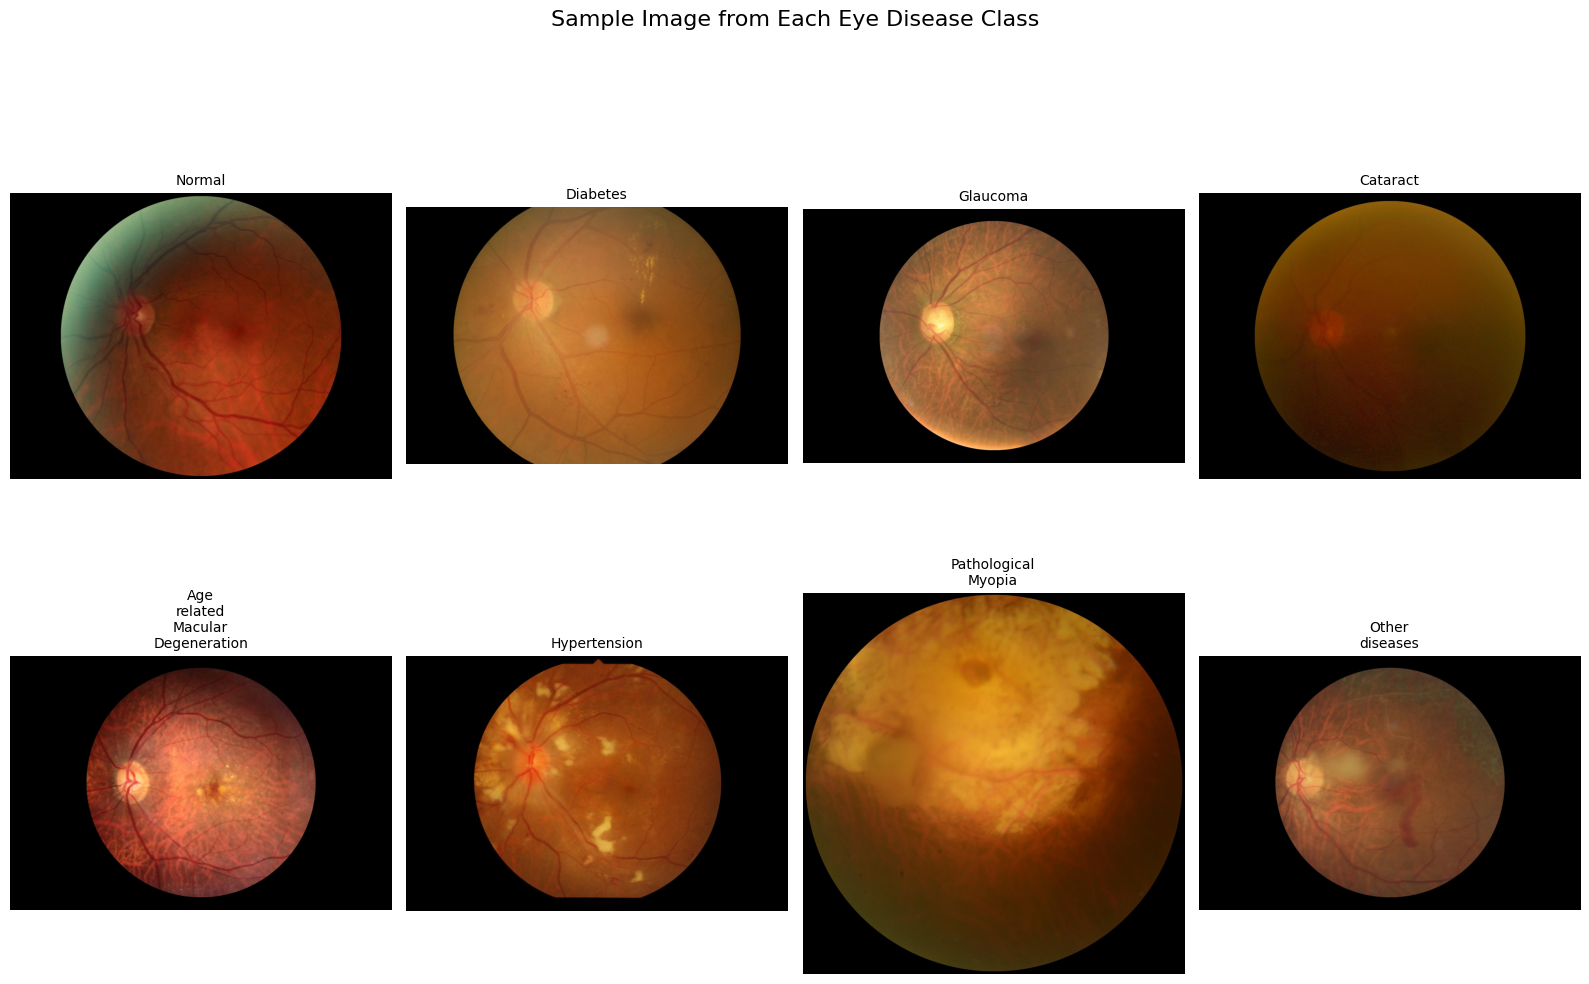

In [2]:
# Display some images from each class in the multi-label classification dataset
# Root directory path
root_path = '/Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/multi_label_classification'

# List of classes (as provided)
disease_classes = [
    'Normal',
    'Diabetes',
    'Glaucoma',
    'Cataract',
    'Age_related_Macular_Degeneration',
    'Hypertension',
    'Pathological_Myopia',
    'Other_diseases'
]

# Create a figure to plot all class samples
plt.figure(figsize=(16, 10))

for i, disease in enumerate(disease_classes):
    class_path = os.path.join(root_path, disease)

    # Check both left_eye and right_eye folders
    left_eye_path = os.path.join(class_path, 'left_eye')
    right_eye_path = os.path.join(class_path, 'right_eye')

    # Collect all valid image files (exclude files starting with ._)
    left_images = [f for f in os.listdir(left_eye_path) if f.lower().endswith(('.jpg', '.png', '.jpeg')) and not f.startswith('._')]
    right_images = [f for f in os.listdir(right_eye_path) if f.lower().endswith(('.jpg', '.png', '.jpeg')) and not f.startswith('._')]

    # Pick one image randomly from left_eye or right_eye
    chosen_folder = left_eye_path if left_images else right_eye_path
    chosen_images = left_images if left_images else right_images

    if not chosen_images:
        print(f"No valid images found for class: {disease}")
        continue

    sample_image_path = os.path.join(chosen_folder, random.choice(chosen_images))

    # Load and plot the image
    image = Image.open(sample_image_path).convert("RGB")
    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(disease.replace('_', '\n'), fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Sample Image from Each Eye Disease Class", fontsize=16, y=1.05)
plt.show()


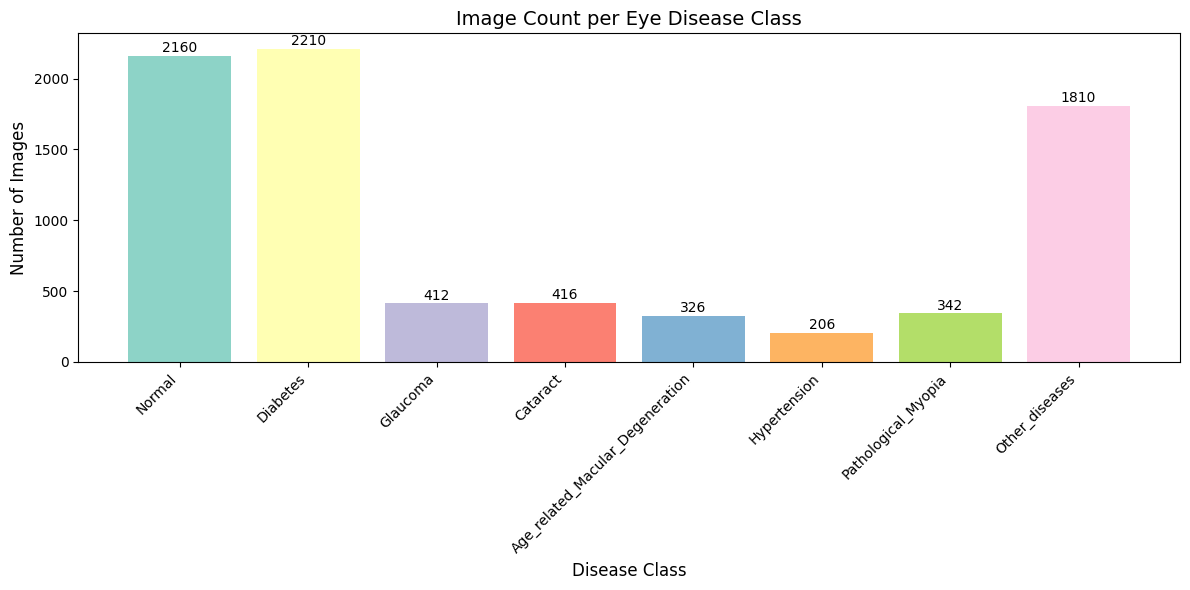

In [5]:
# Count of the image in each class

# Root directory
root_path = '/Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/multi_label_classification'

# Initialize dictionary to hold image counts
class_counts = {}

# Loop through each disease class folder
for class_name in os.listdir(root_path):
    class_path = os.path.join(root_path, class_name)

    if not os.path.isdir(class_path):
        continue

    left_eye_path = os.path.join(class_path, 'left_eye')
    right_eye_path = os.path.join(class_path, 'right_eye')

    left_images = [f for f in os.listdir(left_eye_path) if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._')] if os.path.exists(left_eye_path) else []
    right_images = [f for f in os.listdir(right_eye_path) if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._')] if os.path.exists(right_eye_path) else []

    total_count = len(left_images) + len(right_images)
    class_counts[class_name] = total_count

# Prepare data
classes = list(class_counts.keys())
counts = list(class_counts.values())

# Create colormap
cmap = plt.get_cmap('Set3')  # Try 'tab10', 'Set2', 'viridis', etc.
colors = [cmap(i) for i in range(len(classes))]

# Plotting
plt.figure(figsize=(12, 6))
bars = plt.bar(classes, counts, color=colors)
plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Image Count per Eye Disease Class', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(height), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


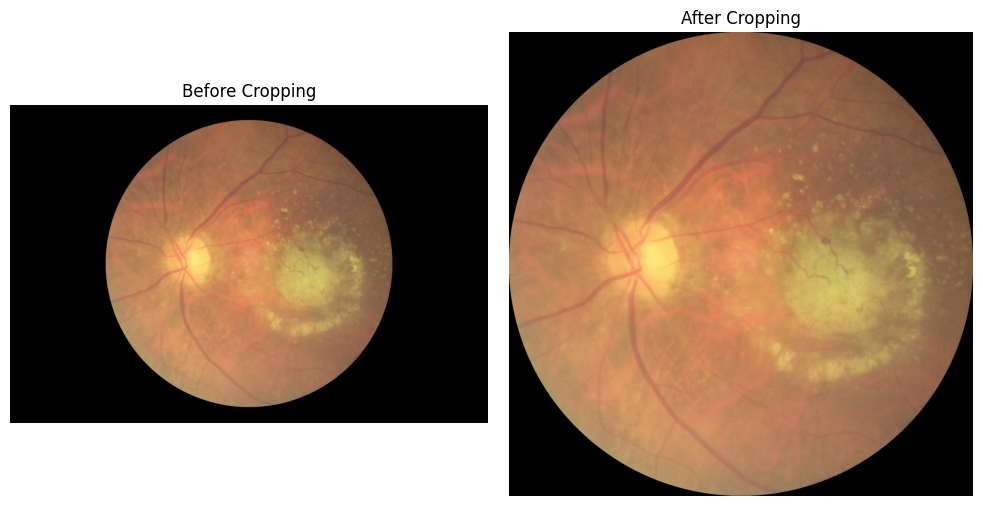

In [7]:
# try to crop the image black background area



# Path to your uploaded image
image_path = '/Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/multi_label_classification/Age_related_Macular_Degeneration/left_eye/43_left.jpg'

# Load image using OpenCV
image = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Threshold to create binary mask of non-black regions
_, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

# Find contours from binary mask
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Assume largest contour is the retina
c = max(contours, key=cv2.contourArea)

# Get bounding box and crop
x, y, w, h = cv2.boundingRect(c)
cropped_image = image[y:y+h, x:x+w]

# Convert BGR (OpenCV) to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cropped_rgb = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)

# Plot original and cropped images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Before Cropping')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cropped_rgb)
plt.title('After Cropping')
plt.axis('off')

plt.tight_layout()
plt.show()


Processing Cataract/right_eye: 100%|██████████| 208/208 [00:04<00:00, 47.51it/s]
Processing Age_related_Macular_Degeneration/left_eye: 100%|██████████| 163/163 [00:03<00:00, 51.07it/s]
Processing Age_related_Macular_Degeneration/right_eye: 100%|██████████| 163/163 [00:03<00:00, 50.27it/s]
Processing Other_diseases/right_eye: 100%|██████████| 905/905 [00:17<00:00, 50.85it/s]


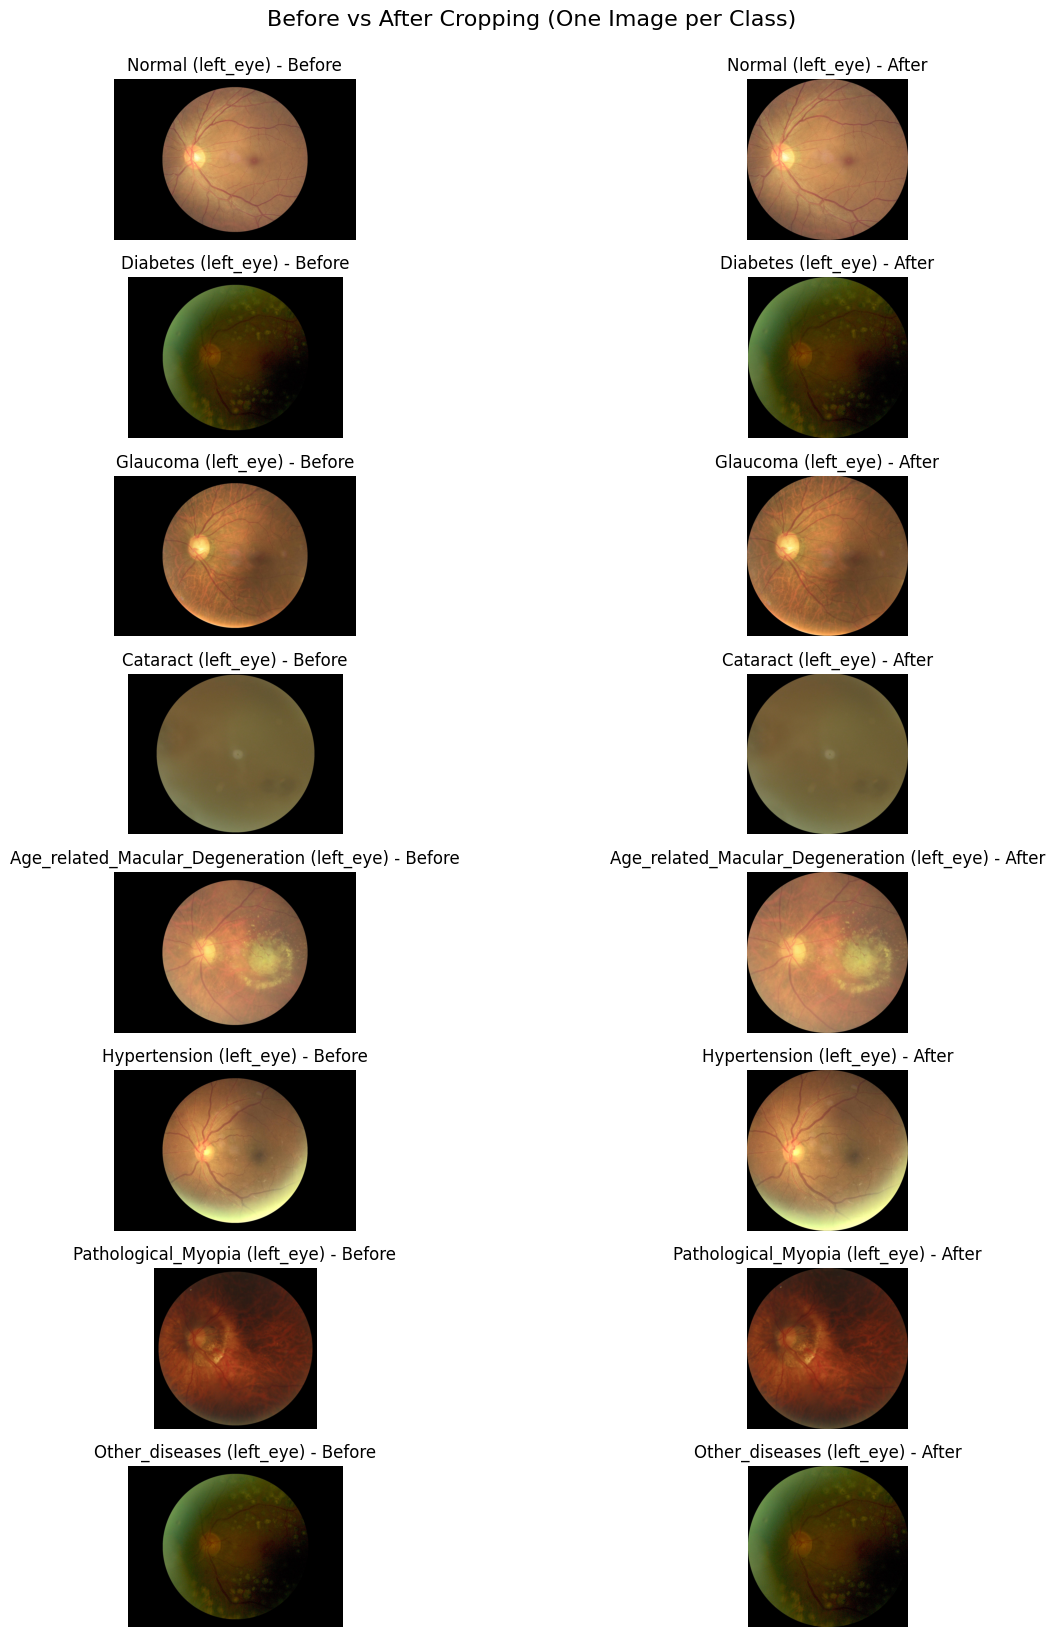

In [9]:
# Crop the images in the dataset

# Source and destination paths
src_root = '/Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/multi_label_classification'
dst_root = '/Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/crop_image_data'

# Create destination root if not exist
os.makedirs(dst_root, exist_ok=True)

# Track one sample per class for visualization
sample_images = {}

# Loop through each class folder
for class_name in os.listdir(src_root):
    class_path = os.path.join(src_root, class_name)
    if not os.path.isdir(class_path):
        continue

    # Create destination class folder
    dst_class_path = os.path.join(dst_root, class_name)
    os.makedirs(dst_class_path, exist_ok=True)

    for eye in ['left_eye', 'right_eye']:
        eye_path = os.path.join(class_path, eye)
        if not os.path.exists(eye_path):
            continue

        dst_eye_path = os.path.join(dst_class_path, eye)
        os.makedirs(dst_eye_path, exist_ok=True)

        # List image files
        image_files = [f for f in os.listdir(eye_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._')]

        for img_name in tqdm(image_files, desc=f'Processing {class_name}/{eye}'):
            img_path = os.path.join(eye_path, img_name)
            dst_img_path = os.path.join(dst_eye_path, img_name)

            try:
                image = cv2.imread(img_path)
                if image is None:
                    continue

                # Grayscale + threshold + contour
                gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
                contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                if not contours:
                    continue

                c = max(contours, key=cv2.contourArea)
                x, y, w, h = cv2.boundingRect(c)
                cropped = image[y:y+h, x:x+w]

                # Save cropped image
                cv2.imwrite(dst_img_path, cropped)

                # Store one sample per class for plot
                if class_name not in sample_images and random.random() < 0.5:
                    sample_images[class_name] = {
                        'original': image,
                        'cropped': cropped,
                        'title': f"{class_name} ({eye})"
                    }

            except Exception as e:
                print(f"Failed processing {img_path}: {e}")

# Plot one before & after image per class
plt.figure(figsize=(16, len(sample_images)*2))

for i, (class_name, data) in enumerate(sample_images.items()):
    original_rgb = cv2.cvtColor(data['original'], cv2.COLOR_BGR2RGB)
    cropped_rgb = cv2.cvtColor(data['cropped'], cv2.COLOR_BGR2RGB)

    plt.subplot(len(sample_images), 2, 2*i + 1)
    plt.imshow(original_rgb)
    plt.title(f"{data['title']} - Before")
    plt.axis('off')

    plt.subplot(len(sample_images), 2, 2*i + 2)
    plt.imshow(cropped_rgb)
    plt.title(f"{data['title']} - After")
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Before vs After Cropping (One Image per Class)", fontsize=16, y=1.02)
plt.show()


In [ ]:
# Remove all files starting with ._ in the cropped image data directory

# Path to the cropped image data
clean_root = '/Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/crop_image_data'

# Walk through all subdirectories
for root, dirs, files in os.walk(clean_root):
    for filename in files:
        if filename.startswith('._'):
            file_path = os.path.join(root, filename)
            try:
                os.remove(file_path)
                print(f"Removed: {file_path}")
            except Exception as e:
                print(f"Failed to remove {file_path}: {e}")


Removed: /Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/crop_image_data/Normal/._left_eye
Removed: /Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/crop_image_data/Normal/._right_eye
Removed: /Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/crop_image_data/Normal/left_eye/._1_left.jpg
Removed: /Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/crop_image_data/Normal/left_eye/._8_left.jpg
Removed: /Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/crop_image_data/Normal/left_eye/._84_left.jpg
Removed: /Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/crop_image_data/Normal/left_eye/._191_left.jpg
Removed: /Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/crop_image_data/Normal/left_eye/._394_left.jpg
Removed: /Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/crop_image_data/Normal/left_e


Top 10 Most Common Image Sizes:
Size: (1553, 1553) → 549 images
Size: (1553, 1554) → 515 images
Size: (1555, 1554) → 218 images
Size: (1554, 1554) → 215 images
Size: (1553, 1555) → 200 images
Size: (1555, 1555) → 177 images
Size: (1554, 1553) → 173 images
Size: (1555, 1553) → 139 images
Size: (1554, 1555) → 130 images
Size: (1551, 1551) → 104 images


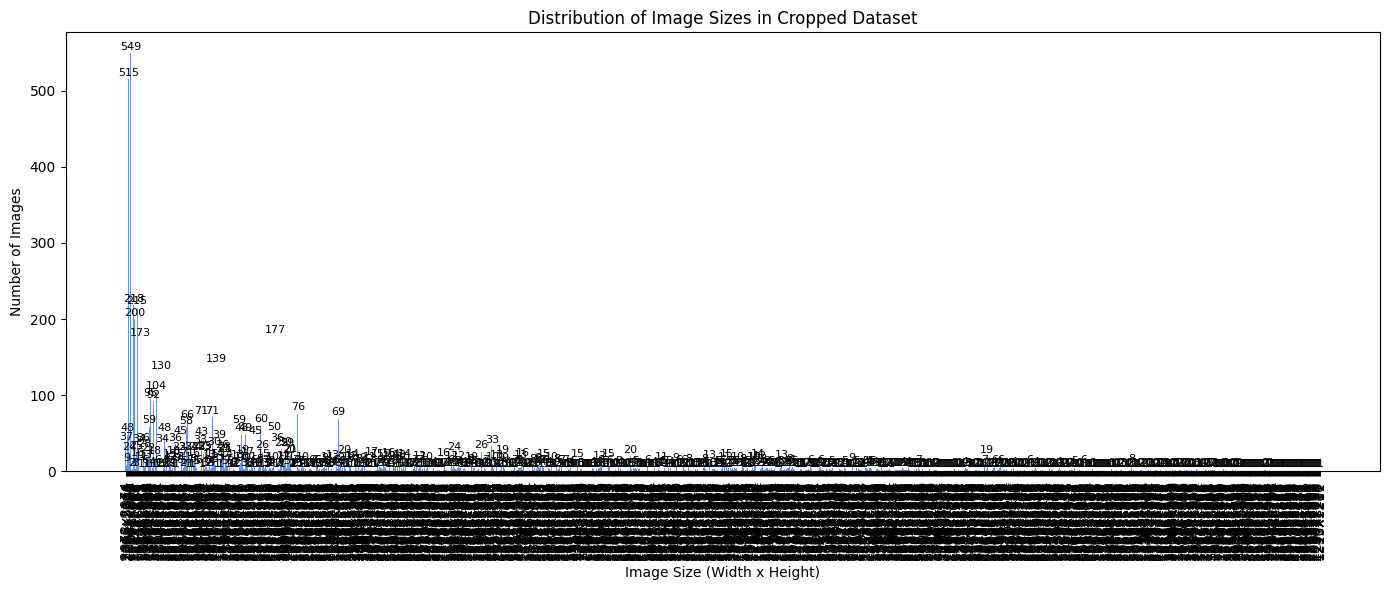

In [14]:
# Check the image size of the cropped images



# Path to cropped image data
image_dir = '/Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/crop_image_data'

# Collect image sizes
size_counter = Counter()

# Traverse all images
for root, dirs, files in os.walk(image_dir):
    for filename in files:
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')) and not filename.startswith('._'):
            try:
                image_path = os.path.join(root, filename)
                with Image.open(image_path) as img:
                    size = img.size  # (width, height)
                    size_counter[size] += 1
            except Exception as e:
                print(f"Error reading {image_path}: {e}")

# Show most common sizes
print("\nTop 10 Most Common Image Sizes:")
for size, count in size_counter.most_common(10):
    print(f"Size: {size} → {count} images")

# Plot
sizes = [f"{w}x{h}" for (w, h) in size_counter.keys()]
counts = list(size_counter.values())

plt.figure(figsize=(14, 6))
bars = plt.bar(sizes, counts, color='cornflowerblue')
plt.xticks(rotation=90)
plt.xlabel("Image Size (Width x Height)")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Sizes in Cropped Dataset")

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
